# Composite vertical anomalous temperature structure of The Blob in FOSI

### 0. Set up

In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw
import json 
from IPython.utils import io
from os.path import exists
from scipy.stats import gaussian_kde
import seaborn as sns
import netCDF4 as nc4
from scipy import stats, interpolate

### 0.1 Functions

In [2]:
def pop_find_lat_ind(loc, LATDAT): # from Anna's notebook
    return np.abs(LATDAT[:, 0].values - loc).argmin()

def pop_find_lon_ind(loc, LONDAT, direction="w"): # from Anna's notebook
    if direction.lower() in ["east", "e"]:
        value = loc
    elif direction.lower() in ["west", "w"]:
        value = 360 - loc
    else:
        print("I do not know which direction.")
    return np.nanargmin(np.abs(LONDAT[0, :].values - value))

In [3]:
# Accessing glade CESM LENS2
def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']

    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()

    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])

        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])

    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)

    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)

    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut

def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices

def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths,
                                 concat_dim='time',
                                 combine='nested',
                                 parallel=True)
    return var_ds

In [4]:
def setup_axes(ax): # from Jacob's notebook
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def lons_to_360(data, coord='lon'): # from Jacob's notebook
    """ Converts longitude coordinates from (-180, 180) to (0, 360)."""
    data.coords[coord] = (360 + (data.coords[coord] % 360)) % 360
    data = data.sortby(data[coord])
    return data

def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

def pop_find_lat_ind(loc, LATDAT): # from Anna's notebook
    return np.abs(LATDAT[:, 0].values - loc).argmin()

def pop_find_lon_ind(loc, LONDAT, direction="w"): # from Anna's notebook
    if direction.lower() in ["east", "e"]:
        value = loc
    elif direction.lower() in ["west", "w"]:
        value = 360 - loc
    else:
        print("I do not know which direction.")
    return np.nanargmin(np.abs(LONDAT[0, :].values - value))

In [5]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])

    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)

    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})

    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})

    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])

    # compute anomalies by removing all  the model coefficients
    ssta_notrend = sst-model_da.dot(sst_mod)

    # Use the 90th percentile as a threshold and find anomalies that exceed it.
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})

    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])

    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)

    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})

    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})

    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])

    # compute anomalies by removing all  the model coefficients
    ssta_notrend = sst-model_da.dot(sst_mod)

    # Use the 90th percentile as a threshold and find anomalies that exceed it.
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})

    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

def calculate_anomalies_trend_features_4d_with_trend(ds):
    """
    Calculate anomalies, trends, and features for 4D data (time × z_t × lat × lon)

    Parameters:
    ds : xarray.DataArray
        Input data with dimensions (time, z_t, lat, lon)

    Returns:
    mean, trend, seas, features_notrend, ssta_notrend
        All outputs will preserve z_t dimension
    """
    # Ensure we have all required dimensions
    if 'z_t' not in ds.dims:
        raise ValueError("Input data must have 'z_t' dimension")

    # Convert time to decimal years for harmonic analysis
    dyr = ds.time.dt.year + ds.time.dt.month/12

    # Create the 6-coefficient model matrix
    model = np.array([
        np.ones(len(dyr)),
        dyr - np.mean(dyr),
        np.sin(2*np.pi*dyr),
        np.cos(2*np.pi*dyr),
        np.sin(4*np.pi*dyr),
        np.cos(4*np.pi*dyr)
    ])
    # Pseudo-inverse for least squares solution
    pmodel = np.linalg.pinv(model)

    # Convert to DataArrays
    model_da = xr.DataArray(
        model.T,
        dims=['time', 'coeff'],
        coords={'time': ds.time, 'coeff': np.arange(1, 7)}
    )

    pmodel_da = xr.DataArray(
        pmodel.T,
        dims=['coeff', 'time'],
        coords={'coeff': np.arange(1, 7), 'time': ds.time}
    )

    # Calculate coefficients for each depth level
    # Note: This is the key 4D modification - we now dot product with 4D data
    coeffs = xr.dot(pmodel_da, ds)  # Result has dims (coeff, z_t, lat, lon)

    # Construct components (now includes z_t)
    mean = model_da[:, 0].dot(coeffs.sel(coeff=1))  # dims: (z_t, lat, lon)
    trend = model_da[:, 1].dot(coeffs.sel(coeff=2))  # dims: (z_t, lat, lon)
    seas = model_da[:, 2:].dot(coeffs.sel(coeff=slice(3, 6)))  # dims: (time, z_t, lat, lon)

    # Compute full model prediction and anomalies
    full_model = model_da.dot(coeffs)  # dims: (time, z_t, lat, lon)
    ssta_with_trend = ds - full_model + mean

    # Handle chunking if data is dask array
    if ssta_with_trend.chunks:
        ssta_with_trend = ssta_notrend.chunk({'time': -1, 'z_t': -1})

    # Calculate 90th percentile threshold for each depth level
    threshold = ssta_with_trend.quantile(0.9, dim=('time'))  # dims: (z_t, lat, lon)

    # Find features exceeding threshold
    features_withtrend = ssta_with_trend.where(ssta_with_trend >= threshold)

    return mean, trend, seas, features_withtrend, ssta_with_trend

def calculate_anomalies_trend_features_4d(ds):
    """
    Calculate anomalies, trends, and features for 4D data (time × z_t × lat × lon)
    
    Parameters:
    ds : xarray.DataArray
        Input data with dimensions (time, z_t, lat, lon)
        
    Returns:
    mean, trend, seas, features_notrend, ssta_notrend
        All outputs will preserve z_t dimension
    """
    # Ensure we have all required dimensions
    if 'z_t' not in ds.dims:
        raise ValueError("Input data must have 'z_t' dimension")
    
    # Convert time to decimal years for harmonic analysis
    dyr = ds.time.dt.year + ds.time.dt.month/12
    
    # Create the 6-coefficient model matrix
    model = np.array([
        np.ones(len(dyr)),
        dyr - np.mean(dyr),
        np.sin(2*np.pi*dyr),
        np.cos(2*np.pi*dyr),
        np.sin(4*np.pi*dyr),
        np.cos(4*np.pi*dyr)
    ])
    
    # Pseudo-inverse for least squares solution
    pmodel = np.linalg.pinv(model)
        
    # Convert to DataArrays
    model_da = xr.DataArray(
        model.T,
        dims=['time', 'coeff'],
        coords={'time': ds.time, 'coeff': np.arange(1, 7)}
    )
    
    pmodel_da = xr.DataArray(
        pmodel.T,
        dims=['coeff', 'time'],
        coords={'coeff': np.arange(1, 7), 'time': ds.time}
    )
    
    # Calculate coefficients for each depth level
    # Note: This is the key 4D modification - we now dot product with 4D data
    coeffs = xr.dot(pmodel_da, ds)  # Result has dims (coeff, z_t, lat, lon)
    
    # Construct components (now includes z_t)
    mean = model_da[:, 0].dot(coeffs.sel(coeff=1))  # dims: (z_t, lat, lon)
    trend = model_da[:, 1].dot(coeffs.sel(coeff=2))  # dims: (z_t, lat, lon)
    seas = model_da[:, 2:].dot(coeffs.sel(coeff=slice(3, 6)))  # dims: (time, z_t, lat, lon)
    
    # Compute full model prediction and anomalies
    full_model = model_da.dot(coeffs)  # dims: (time, z_t, lat, lon)
    ssta_notrend = ds - full_model
    
    # Handle chunking if data is dask array
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1, 'z_t': -1})

    # Calculate 90th percentile threshold for each depth level
    threshold = ssta_notrend.quantile(0.9, dim=('time'))  # dims: (z_t, lat, lon)
    
    # Find features exceeding threshold
    features_notrend = ssta_notrend.where(ssta_notrend >= threshold)
    
    return mean, trend, seas, features_notrend, ssta_notrend

### 0.2 Loading data

In [8]:
#### CESM LENS2 for GRIDDING PURPOSES
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [9]:
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3 = xr.where(mask_3 > 0.1, 1, 0)

mhw_obj_mask = mask_3
# fosi_blobs = xr.open_dataset('fosi_blobs.nc').labels
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc') # 112 final events

In [10]:
#### FOSI
firstyear = 1979
lastyear = 2020

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

In [11]:
field = 'TEMP'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_temp = xr.open_dataset(fpath+fname)[field].isel(z_t=slice(0, 20))

In [12]:
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi_temp['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi_temp[ds_smyle_fosi_temp.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

In [13]:
fosi_anom_1deg_wzeros_temp = regrid_SMYLE(ds_smyle_fosi_temp)

In [14]:
fosi_anom_1deg_temp = fosi_anom_1deg_wzeros_temp.where(fosi_anom_1deg_wzeros_temp!=0, np.nan)

regridder_temp = xe.Regridder(fosi_anom_1deg_temp.sel(time=slice('1979-01-01','2020-12-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded_temp = regridder_temp(fosi_anom_1deg_temp.sel(time=slice('1979-01-01','2020-12-01')))

In [15]:
# regridded_temp_in_mask_region = regridded_temp*mhw_obj_mask
smaller_region_temp = regridded_temp.sel(lat = slice(12, 65), lon=slice(155, 245))

mean, trend, seas, features, anomalies = calculate_anomalies_trend_features_4d(smaller_region_temp)

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [16]:
# mean_wt, trend_wt, seas_wt, features_withtrend_wt, ssta_with_trend_wt = calculate_anomalies_trend_features_4d_with_trend(smaller_region_temp)

In [17]:
smaller_mhw_obj_mask = mhw_obj_mask.sel(lat = slice(12, 65), lon=slice(155, 245))

In [18]:
anomalies_region = smaller_mhw_obj_mask*anomalies

In [19]:
anomalies_region_nan = xr.where(anomalies_region == 0., np.nan, anomalies_region)

In [20]:
anomalies_region_nan.sel(
    time=slice('2014-01', '2016-04')).mean(dim=('lat','lon')).std()

<xarray.DataArray ()> Size: 8B
array(0.317213)

In [21]:
field = 'HMXL'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_hxml = xr.open_dataset(fpath+fname)[field]

In [22]:
ds_smyle_fosi_hxml['time'] = fosi_montime_vals
fosi_mld = ds_smyle_fosi_hxml[ds_smyle_fosi_hxml.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

In [23]:
fosi_anom_1deg_wzeros_mld = regrid_SMYLE(fosi_mld)

In [24]:
fosi_anom_1deg_mld = fosi_anom_1deg_wzeros_mld.where(fosi_anom_1deg_wzeros_mld!=0, np.nan)

regridder_mld = xe.Regridder(fosi_anom_1deg_mld.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded_mld = regridder_mld(fosi_anom_1deg_mld.sel(time=slice('1979-01-01','2021-01-01')))

In [25]:
mld_region = (smaller_mhw_obj_mask*regridded_mld)/100

In [26]:
mld_region_nan = mld_region.where(mld_region!=0, np.nan)


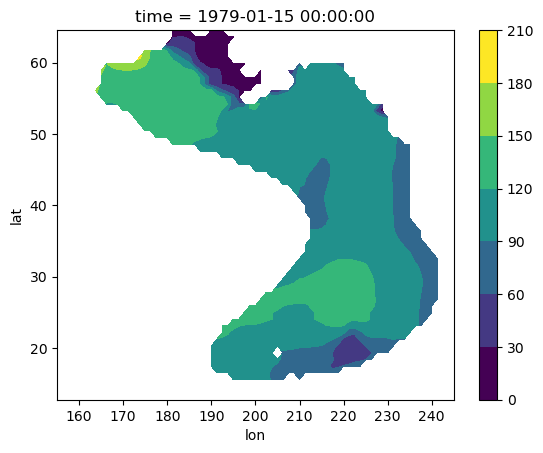

In [27]:
mld_region_nan[:,:,0].plot.contourf()

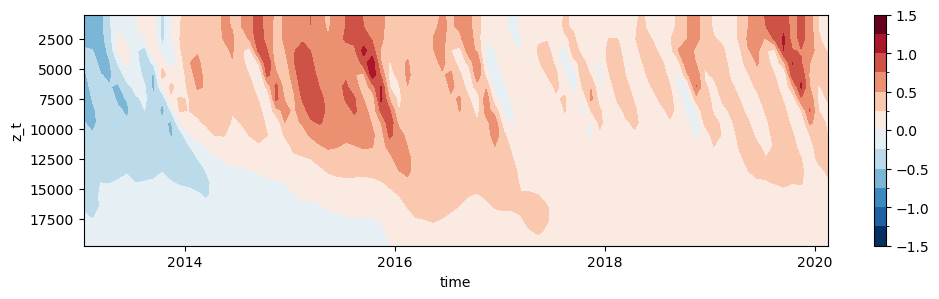

In [28]:
plt.figure(figsize=(12,3))
anomalies_region_nan.mean(dim=('lat','lon')).sel(
    time=slice('2013-01', '2020-02')).transpose().plot.contourf(yincrease=False, levels=13, vmin=-1.5, vmax=1.5, cmap='RdBu_r')
plt.show()

In [35]:
anomalies_region_nan.sel(
    time=slice('2014-06', '2015-12')).max()

<xarray.DataArray ()> Size: 8B
array(2.71160742)

In [80]:
# Get indices where condition is True
high_indices = np.where(anomalies_region_nan.sel(
    time=slice('2014-06', '2015-12')) > 2.7)

# If you want the actual coordinates
for idx in zip(*high_indices):
    print(f"Value: {anomalies_region_nan.values[idx]}, at indices: {idx}")

Value: -0.43251635242998354, at indices: (36, 55, 15, 4)


(array([1., 1., 2., 2., 3., 1., 3., 2., 3., 1.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

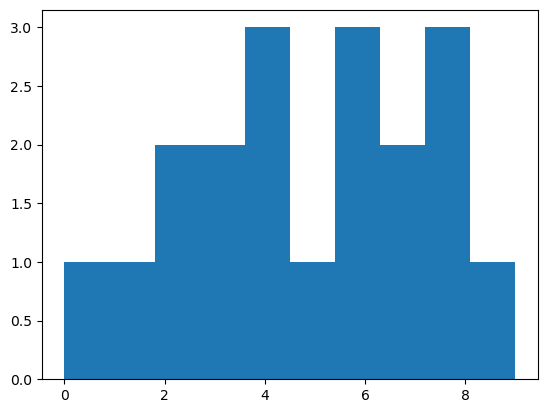

In [94]:
plt.hist(anomalies_region_nan.sel(
    time=slice('2014-06', '2015-12')).mean(dim=('lat','lon')).argmax(dim='z_t').data)

In [96]:
anomalies_region_nan.z_t[8]

<xarray.DataArray 'z_t' ()> Size: 4B
array(8500., dtype=float32)
Coordinates:
    z_t      float32 4B 8.5e+03

In [58]:
anomalies_region_nan.mean(dim=('lat','lon')).max()

<xarray.DataArray ()> Size: 8B
array(1.16722472)

In [50]:
anomalies_region_nan.z_t[4]

<xarray.DataArray 'z_t' ()> Size: 4B
array(4500., dtype=float32)
Coordinates:
    z_t      float32 4B 4.5e+03

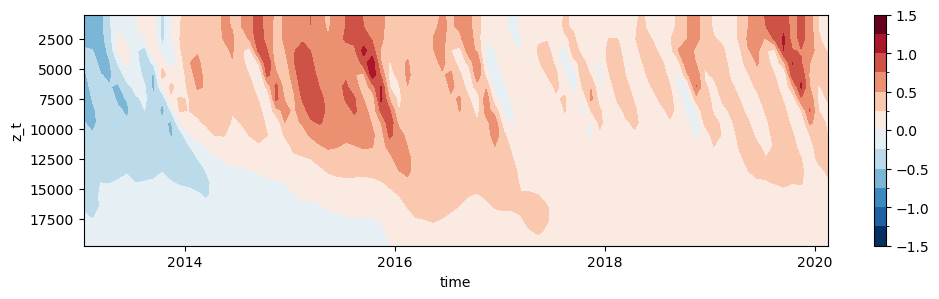

In [25]:
plt.figure(figsize=(12,3))
anomalies_region_nan.mean(dim=('lat','lon')).sel(
    time=slice('2013-01', '2020-02')).transpose().plot.contourf(yincrease=False, levels=13, vmin=-1.5, vmax=1.5, cmap='RdBu_r')
plt.show()

In [114]:
anomalies_region_nan.sel(
    time=slice('2014-06', '2015-12')).max()

<xarray.DataArray ()> Size: 8B
array(2.71160742)

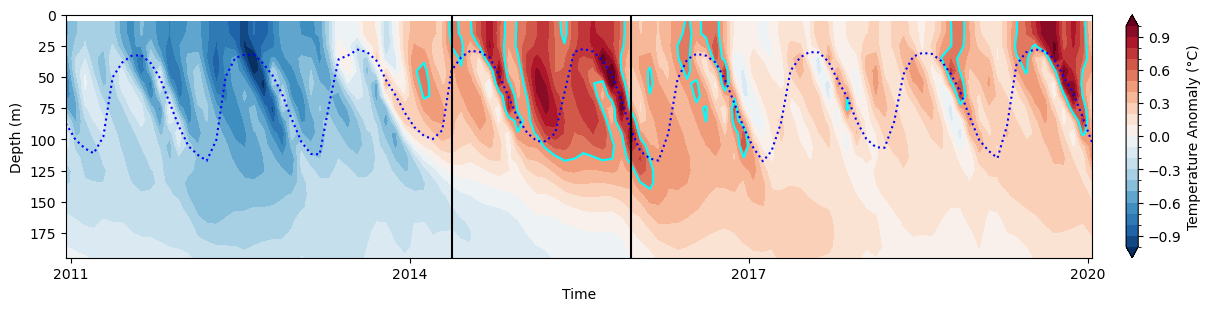

In [69]:
# Set up figure
plt.figure(figsize=(12, 3), constrained_layout=True)

# Get the data (assuming depth is in cm in the original data)
data = anomalies_region_nan[:,:].sel(time=slice('2010-12', '2020-01')).mean(dim=('lat','lon')).transpose()
# data = features.sel(time=slice('2012-12', '2020-12'))[:,:25].mean(dim=('lat','lon')).transpose()
data["z_t"] = data["z_t"] / 100
data["z_t"].attrs["units"] = "m"

# Create contour plot
contour = data.plot.contourf(
    levels=np.linspace(-1., 1., 21),
    vmin=-1.,
    vmax=1.,
    cmap='RdBu_r',
    # cmap=cmocean.cm.thermal,
    add_colorbar=False,
    extend='both'
)

# data = features[:,:25].mean(dim=('lat','lon')).transpose()

# Create contour plot
contour_lines = data.plot.contour(
    levels=np.linspace(0.5, 1.5, 2),
    vmin=0.5,
    vmax=1.5,
    # cmap=cmocean.cm.balance,
    cmap='cyan',
    add_colorbar=False,
    extend=False,
    # extend='both'
)


# Add colorbar
cbar = plt.colorbar(contour, ax=plt.gca(), pad=0.02)
cbar.set_label('Temperature Anomaly (°C)', fontsize=10)
cbar.ax.tick_params(labelsize=10)

# Format axes
ax = plt.gca()
ax.invert_yaxis()  # Depth increases downward


# # Convert y-axis labels from cm to m
# current_yticks = ax.get_yticks()
# ax.set_yticklabels([f'{int(tick/100)}' for tick in current_yticks])
ax.set_ylabel('Depth (m)', fontsize=10)
ax.set_xlabel('Time', fontsize=10)
# # Date formatting
# ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[6]))

# Grid and reference lines
# ax.grid(True, which='major', linestyle=':', color='gray', alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.plot(mld_region_nan.mean(dim=('lat','lon')).sel(time=slice('2010-12', '2020-01')).time, 
         mld_region_nan.mean(dim=('lat','lon')).sel(time=slice('2010-12', '2020-01')), 
         c='blue', linestyle='dotted')
# Title

plt.axvline(x = features.time.sel(time='2014-05').item(), c='k')
plt.axvline(x = features.time.sel(time='2015-12').item(), c='k')

# plt.axvline(x = features.time.sel(time='2014-12').item(), c='k')
# plt.axvline(x = features.time.sel(time='2015-11').item(), c='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(195, 0)
plt.show()

In [29]:
object_id = 94. # for 2
blobs = fosi_blobs
object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
# print(len(true_time_steps))
# print(true_time_steps)
# only_ts = regridded_ssta_no_trend_NEP.sel(time=true_time_steps.time)
one_obj = blobs.sel(time=true_time_steps.time)
blobs_nan = xr.where(one_obj == object_id, 1., 0.)

In [30]:
smaller_regridded_ml = regridded_mld.sel(lat = slice(12, 65), lon=slice(155, 245))

In [31]:
mixed_layer_depth_during = mld_region_nan.sel(time=slice('2014-04','2016-02')).mean(dim=('lat','lon'))

In [32]:
def three_phases(region_area_data):
    pre_mhw_event_mld = region_area_data.isel(time=slice(0,2)).mean(dim='time')
    duration_mhw_mld = region_area_data.isel(time=slice(2,-2)).mean(dim='time')
    post_mhw_event_mld = region_area_data.isel(time=slice(-2,None)).mean(dim='time')
    
    var_dataxr = [pre_mhw_event_mld, 
                  duration_mhw_mld,
                  post_mhw_event_mld
                 ]

    var_data = xr.concat(var_dataxr, dim='time_ind')
    return var_data

In [33]:
var_temp_3phases = three_phases(
    anomalies_region_nan.sel(time=slice('2014-04','2016-02')))

In [34]:
max_depth_by_time = anomalies_region_nan.sel(time=slice('2014-04','2016-02')).mean(dim=('lat','lon')).argmax(dim='z_t')

(array([1., 1., 2., 2., 3., 1., 3., 2., 3., 1.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

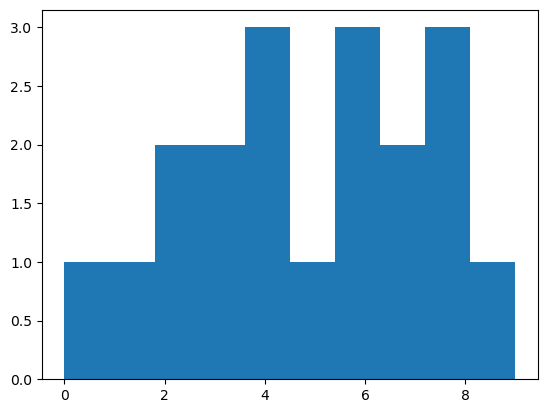

In [35]:
plt.hist(max_depth_by_time[2:-2])

In [36]:
max_depth_by_time_val = anomalies_region_nan.sel(time=slice('2014-04','2016-02')).mean(dim=('lat','lon')).max(dim='z_t')

In [37]:
max_depth_by_time_val[18]

<xarray.DataArray ()> Size: 8B
array(1.16722472)
Coordinates:
    time     object 8B 2015-10-15 00:00:00

In [38]:
max_depth_by_time_val[2:-2].std()

<xarray.DataArray ()> Size: 8B
array(0.18116321)

In [39]:
max_depth_by_time[2:-2].mean()

<xarray.DataArray ()> Size: 8B
array(4.89473684)

In [41]:
var_mld_3phases = three_phases(
    mld_region_nan.sel(time=slice('2014-04','2016-02'))).mean(dim=('lat','lon'))

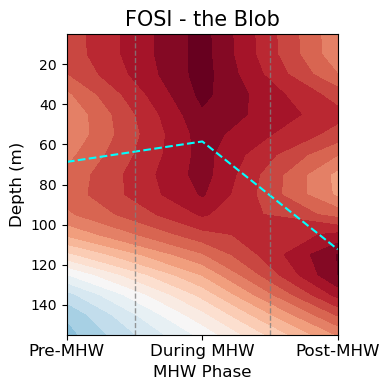

In [42]:
fig, ax = plt.subplots(figsize=(4, 4))

contour = var_temp_3phases.mean(dim=('lat','lon')).transpose().plot.contourf(
    ax=ax,
    yincrease=False,
    cmap='RdBu_r',
    robust=True,
    levels=25, 
    vmin=-0.6, vmax=0.6,
    add_colorbar=False
)

(var_mld_3phases*100).plot(c='cyan', linestyle='dashed')
for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

ax.set_xticks([0., 1., 2,])
ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=12)

ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200], fontsize=10)
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)

# Layout and limits
plt.ylim(15500, 500)
# plt.title('>100m', fontsize=15)

plt.title('FOSI - the Blob', fontsize=15)
plt.tight_layout()
plt.show()

In [49]:
var_temp_5phases = five_phases(
    anomalies_region_nan.sel(time=slice('2014-04','2016-02')), 
    18)

great


In [50]:
var_mld_5phases = five_phases(
    mld_region_nan.sel(time=slice('2014-04','2016-02')), 
    18)

great


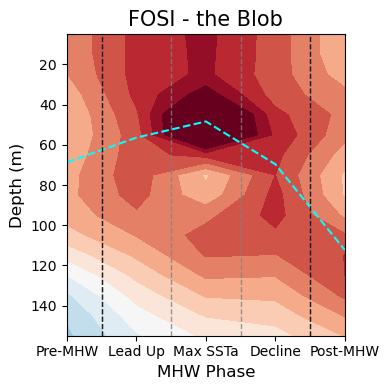

In [53]:
fig, ax = plt.subplots(figsize=(4, 4))

contour = var_temp_5phases.mean(dim=('lat','lon')).transpose().plot.contourf(
    ax=ax,
    yincrease=False,
    cmap='RdBu_r',
    robust=True,
    levels=17, 
    vmin=-0.8, vmax=0.8,
    add_colorbar=False
)
# for x in [0.5, 1.5]:
#     ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

# ax.set_xticks([0., 1., 2,])
# ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=12)
(var_mld_5phases*100).mean(dim=('lat','lon')).plot(c='cyan', linestyle='dashed')

for x in [0.5, 1.5, 2.5, 3.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

for x in [0.5, 3.5]:
    ax.axvline(x, color='k', linestyle='--', linewidth=1., alpha=0.8)

ax.set_xticks([0., 1., 2,3, 4])
ax.set_xticklabels(["Pre-MHW", "Lead Up", "Max SSTa", "Decline", "Post-MHW"], fontsize=10)


ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000])
ax.set_yticklabels([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200], fontsize=10)
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)

# Layout and limits
plt.ylim(15500, 500)
# plt.title('>100m', fontsize=15)

plt.title('FOSI - the Blob', fontsize=15)
plt.tight_layout()
plt.show()

In [64]:
max_depth_by_time = anomalies_region_nan.sel(time=slice('2014-04','2016-02')).mean(dim=('lat','lon')).argmax(dim='z_t')

In [68]:
max_depth_by_time[2:-2].max()

<xarray.DataArray ()> Size: 8B
array(9)

In [71]:
anomalies_region_nan.z_t[9]

<xarray.DataArray 'z_t' ()> Size: 4B
array(9500., dtype=float32)
Coordinates:
    z_t      float32 4B 9.5e+03

In [45]:
def five_phases(region_area_data, peak_time):
    if peak_time == 2:
        print('yeah')
        pre_mhw_event_mld = region_area_data.isel(time=slice(0,2)).mean(dim='time')
        lead_up_mhw_event_mld = pre_mhw_event_mld*0
        max_mhw_event_mld = region_area_data.isel(time=peak_time)
        decline_mhw_event_mld = region_area_data.isel(time=slice(peak_time, -2)).mean(dim='time')
        post_mhw_event_mld = region_area_data.isel(time=slice(-2,None)).mean(dim='time')
    elif peak_time > 2 and peak_time < len(region_area_data.time)-2:
        print('great')
        pre_mhw_event_mld = region_area_data.isel(time=slice(0,2)).mean(dim='time')
        lead_up_mhw_event_mld = region_area_data.isel(time=slice(2,peak_time)).mean(dim='time')
        max_mhw_event_mld = region_area_data.isel(time=peak_time)
        decline_mhw_event_mld = region_area_data.isel(time=slice(peak_time, -2)).mean(dim='time')
        post_mhw_event_mld = region_area_data.isel(time=slice(-2,None)).mean(dim='time')
    elif peak_time == len(region_area_data.time)-2:
        print('not so great')
        pre_mhw_event_mld = region_area_data.isel(time=slice(0,2)).mean(dim='time')
        lead_up_mhw_event_mld = region_area_data.isel(time=slice(2,peak_time)).mean(dim='time')
        max_mhw_event_mld = region_area_data.isel(time=peak_time)
        decline_mhw_event_mld = pre_mhw_event_mld*0
        post_mhw_event_mld = region_area_data.isel(time=slice(-2,None)).mean(dim='time')
    else:
        print('excellent')
        pre_mhw_event_mld = region_area_data.isel(time=slice(0,2)).mean(dim='time')
        lead_up_mhw_event_mld = region_area_data.isel(time=slice(2,peak_time)).mean(dim='time')
        max_mhw_event_mld = region_area_data.isel(time=peak_time)
        decline_mhw_event_mld = region_area_data.isel(time=slice(peak_time, -2)).mean(dim='time')
        post_mhw_event_mld = region_area_data.isel(time=slice(-2,None)).mean(dim='time')

    var_dataxr = [pre_mhw_event_mld, 
                  lead_up_mhw_event_mld, 
                  max_mhw_event_mld, 
                  decline_mhw_event_mld,
                  post_mhw_event_mld
                 ]

    var_data = xr.concat(var_dataxr, dim='time_ind')
    return var_data

In [52]:
anomalies_region_nan.sel(time=slice('2014-04','2016-02'))

<xarray.DataArray (lat: 56, lon: 73, time: 23, z_t: 20)> Size: 15MB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * lat      (lat) float64 448B 12.72 13.66 14.61 15.55 ... 62.67 63.61 64.55
  * lon      (lon) float64 584B 155.0 156.2 157.5 158.8 ... 242.5 243.8 245.0
  * z_t      (z_t) float32 80B 500.0 1.5e+03 2.5e+03 ... 1.863e+04 1.977e+04
  * time     (time) object 184B 2014-04-15 00:00:00 ... 2016-02-15 00:00:00

In [ ]:
mld_region_nan
anomalies_region_nan

In [38]:
# mld_sel = smaller_regridded_ml.shift(time=i).sel(time=blobs_nan.labels.time[time_index].item())* blobs_nan.labels[0]
# mld_val = xr.where(mld_sel == 0., np.nan, mld_sel).mean()/100

In [46]:
anomalies_depth = []
mld_depth = []
for i in [-3, -2, -1]:
    time_index = 0
    tmin1_anomalies = anomalies.shift(time=i).sel(time=blobs_nan.labels.time[time_index].item())* blobs_nan.labels[0]
    anomalies_in_region_nan = xr.where(tmin1_anomalies == 0., np.nan, tmin1_anomalies)
    anomalies_depth.append(anomalies_in_region_nan.mean(dim=('lat','lon')))
    
    mld_sel = smaller_regridded_ml.shift(time=i).sel(time=blobs_nan.labels.time[time_index].item())* blobs_nan.labels[0]
    mld_val = xr.where(mld_sel == 0., np.nan, mld_sel).mean()/100
    mld_depth.append(mld_val.item())
    
for time_index in range(20):
    anomalies_in_region = anomalies.sel(time=blobs_nan.labels.time[time_index].item()) * blobs_nan.labels[time_index]
    anomalies_in_region_nan = xr.where(anomalies_in_region == 0., np.nan, anomalies_in_region)
    anomalies_depth.append(anomalies_in_region_nan.mean(dim=('lat','lon')))
    mld_sel = smaller_regridded_ml.shift(time=i).sel(time=blobs_nan.labels.time[time_index].item())* blobs_nan.labels[time_index]
    mld_val = xr.where(mld_sel == 0., np.nan, mld_sel).mean()/100
    mld_depth.append(mld_val.item())
    
for i in [1, 2, 3]:
    time_index = len(blobs_nan.time)-1
    tmin1_anomalies = anomalies.shift(time=i).sel(time=blobs_nan.labels.time[time_index].item())* blobs_nan.labels[time_index]
    anomalies_in_region_nan = xr.where(tmin1_anomalies == 0., np.nan, tmin1_anomalies)
    anomalies_depth.append(anomalies_in_region_nan.mean(dim=('lat','lon')))
    mld_sel = smaller_regridded_ml.shift(time=i).sel(time=blobs_nan.labels.time[time_index].item())* blobs_nan.labels[time_index]
    mld_val = xr.where(mld_sel == 0., np.nan, mld_sel).mean()/100
    mld_depth.append(mld_val.item())

In [47]:
fosi_temp_anomalies = xr.concat(anomalies_depth, dim='time_ind')

In [48]:
pre_phase = fosi_temp_anomalies.isel(
    time_ind=slice(0, 3)).mean(dim='time_ind')

post_phase = fosi_temp_anomalies.sel(
    time_ind=slice(-4, -1)).mean(dim='time_ind')

In [430]:
pre_phase_mld = fosi_temp_anomalies.isel(
    time_ind=slice(0, 3)).mean(dim='time_ind')

post_phase_mld = fosi_temp_anomalies.sel(
    time_ind=slice(-4, -1)).mean(dim='time_ind')

In [431]:
max_ind = fosi_temp_anomalies[3:23,0:3].mean(dim='z_t').argmax(dim='time_ind').item()
mid2 = fosi_temp_anomalies.sel(time_ind=slice(max_ind+3-1, max_ind+3+2)).mean(dim='time_ind')

In [432]:
mid1 = fosi_temp_anomalies.sel(time_ind=slice(3, max_ind+3-1)).mean(dim='time_ind')
mid3 = fosi_temp_anomalies.sel(time_ind=slice(max_ind+3+2, -4)).mean(dim='time_ind')

In [433]:
mld_depth_array = np.array(mld_depth)
pre_phase_mld = mld_depth_array[0:3].mean()
post_phase_mld = mld_depth_array[-4:-1].mean()
mid2_mld = mld_depth_array[max_ind+3-1: max_ind+3+2].mean()
mid3_mld = mld_depth_array[3: max_ind+3-1].mean()
mid1_mld = mld_depth_array[max_ind+3+2: -4].mean()
mld_combined = [pre_phase_mld, mid1_mld, mid2_mld, mid3_mld, post_phase_mld]

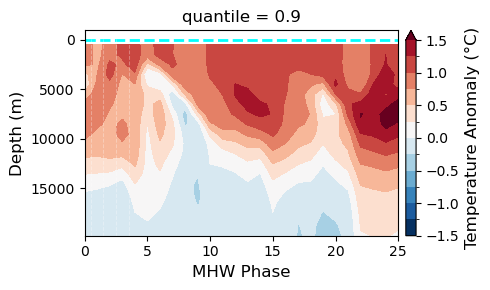

In [54]:
fig, ax = plt.subplots(figsize=(5, 3))
contour = fosi_temp_anomalies.transpose().plot.contourf(
    ax=ax,
        yincrease=False,
        cmap='RdBu_r',
        vmin=-1.5, vmax=1.5, levels=13,
        add_colorbar=False 
    )

cbar = plt.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label("Temperature Anomaly (°C)", fontsize=12)
plt.axhline(y=45, c='cyan', linestyle='dashed', linewidth=2)
for x in [0.5, 1.5, 2.5, 3.5]:
    ax.axvline(x, color='white', linestyle='--', linewidth=0.75, alpha=0.3)
# ax.set_xticks([0., 1., 2, 3, 4])
# ax.set_xticklabels(["Pre", "Lead up", "Max", "Decline", "Post"], fontsize=10)
plt.tight_layout()
# yticks = ax.get_yticks()
# ax.set_yticks(yticks)
# ax.set_yticklabels([f"{int(tick/100)}" for tick in yticks])
# ax.set_yticks([0, 20, 40, 60,80, 100, 120, 140])
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
plt.tight_layout()
plt.show()

In [435]:
combined = xr.concat(
    [pre_phase, mid1, mid2, mid3, post_phase], 
    dim=xr.DataArray(["pre", "mid1", "mid2", "mid3", "post"], 
                     dims="phase"))

In [436]:
new_combined = combined[:,:].transpose()

In [437]:
new_combined["z_t"] = new_combined["z_t"] / 100
new_combined["z_t"].attrs["units"] = "m"

In [438]:
print(new_combined[:,0].max())
print(new_combined[:,0].argmax())
print('')
print(new_combined[:,1].max())
print(new_combined[:,1].argmax())
print('')
print(new_combined[:,2].max())
print(new_combined[:,2].argmax())
print('')
print(new_combined[:,3].max())
print(new_combined[:,3].argmax())
print('')
print(new_combined[:,4].max())
print(new_combined[:,4].argmax())

<xarray.DataArray ()> Size: 8B
array(0.85949151)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'pre'
<xarray.DataArray ()> Size: 8B
array(2)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'pre'

<xarray.DataArray ()> Size: 8B
array(0.99179686)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'mid1'
<xarray.DataArray ()> Size: 8B
array(0)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'mid1'

<xarray.DataArray ()> Size: 8B
array(1.25932797)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'mid2'
<xarray.DataArray ()> Size: 8B
array(6)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'mid2'

<xarray.DataArray ()> Size: 8B
array(1.08961142)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'mid3'
<xarray.DataArray ()> Size: 8B
array(0)
Coordinates:
    quantile  float64 8B 0.9
    phase     <U4 16B 'mid3'

<xarray.DataArray ()> Size: 8B
array(1.49928547)
Coordinates:
    quantile

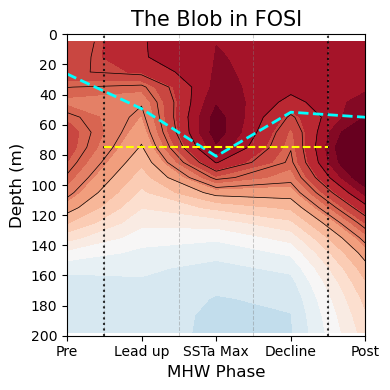

In [441]:
fig, ax = plt.subplots(figsize=(4, 4))
plt.ylim(0, 195)
contour = new_combined.plot.contour(
        ax=ax,
        yincrease=False,
        levels=np.linspace(0.5, 1, 5),
        cmap='k',
        linewidths=0.5
    )
contour = new_combined.plot.contourf(
        ax=ax,
        yincrease=False,                # Depth increases downward
        cmap='RdBu_r',                  # Red-Blue diverging colormap
        robust=True,                    # Ignore outliers in color scaling
        levels=25, 
        vmin=-1.2, vmax=1.2,
        add_colorbar=False              # We'll add it manually later
    )
    
# cbar = plt.colorbar(contour, ax=ax, pad=0.02)
# cbar.set_label("Temperature Anomaly (°C)", fontsize=12)
for x in [0.5, 1.5, 2.5, 3.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=0.75, alpha=0.4)

for x in [0.5, 3.5]:
    ax.axvline(x, color='k', linestyle='dotted', linewidth=1.5, alpha=0.8)
    
ax.set_xticks([0., 1., 2, 3, 4])
ax.set_xticklabels(["Pre", "Lead up", "SSTa Max", "Decline", "Post"], fontsize=10)
plt.tight_layout()
plt.plot([0., 1., 2, 3, 4], mld_combined, c='cyan', linestyle='dashed', linewidth=2)
# yticks = ax.get_yticks()
# ax.set_yticks(yticks)
# ax.set_yticklabels([f"{int(tick/100)}" for tick in yticks])
ax.set_yticks([0, 20, 40, 60,80, 100, 120, 140, 160, 180, 200])
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
plt.tight_layout()
plt.title('The Blob in FOSI', fontsize=15)
ax.hlines(y=75, xmin=0.5, xmax=3.5, color='yellow', linestyle='dashed')
plt.tight_layout()
plt.show()

In [60]:
max_temp_depth = np.argmax((fosi_temp_anomalies[3:-3]).max(dim='time_ind').data)
max_time = np.argmax((fosi_temp_anomalies[3:-3]).max(dim='time_ind').data)

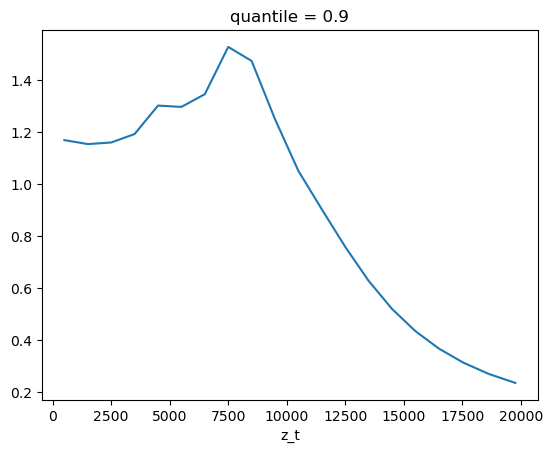

In [62]:
(fosi_temp_anomalies[3:-3]).max(dim='time_ind').plot()

In [31]:
fosi_temp_anomalies.z_t[7]
# 65 to 75

<xarray.DataArray 'z_t' ()> Size: 4B
array(7500., dtype=float32)
Coordinates:
    z_t       float32 4B 7.5e+03
    quantile  float64 8B 0.9

In [258]:
pre_phase = fosi_temp_anomalies.isel(
    time_ind=slice(0, 3)).mean(dim='time_ind')

post_phase = fosi_temp_anomalies.sel(
    time_ind=slice(-4, -1)).mean(dim='time_ind')

mid_phase = fosi_temp_anomalies.sel(
    time_ind=slice(3, -4)).mean(dim='time_ind')

combined = xr.concat(
    [pre_phase, mid_phase, post_phase], 
    dim=xr.DataArray(["pre", "mid", "post"], 
                     dims="phase"))

new_combined = combined[:,:].transpose()

new_combined["z_t"] = new_combined["z_t"] / 100
new_combined["z_t"].attrs["units"] = "m"

mld_depth_array = np.array(mld_depth)
pre_phase_mld = mld_depth_array[0:3].mean()
post_phase_mld = mld_depth_array[-4:-1].mean()
mid_mld = mld_depth_array[3: -4].mean()
mld_combined = [pre_phase_mld, mid_mld, post_phase_mld]

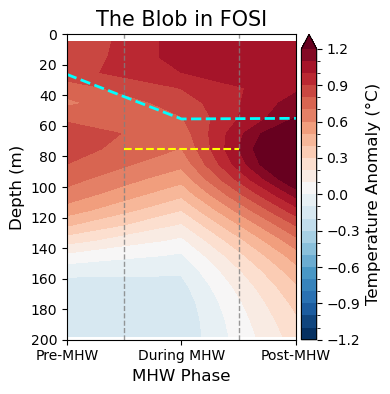

In [426]:
fig, ax = plt.subplots(figsize=(4, 4))
# contour = new_combined.plot.contour(
#         ax=ax,
#         yincrease=False,
#         levels=np.linspace(0.5, 1, 5),
#         cmap='k',
#         linewidths=0.5
#     )
contour = new_combined.plot.contourf(
        ax=ax,
        yincrease=False,                # Depth increases downward
        cmap='RdBu_r',                  # Red-Blue diverging colormap
        robust=True,                    # Ignore outliers in color scaling
        levels=25, 
        vmin=-1.2, vmax=1.2,
        add_colorbar=False              # We'll add it manually later
    )
    
cbar = plt.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label("Temperature Anomaly (°C)", fontsize=12)
for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)
ax.set_xticks([0., 1., 2])
# ax.set_xticklabels(["Pre", "Lead up", "SSTa Max", "Decline",  "Post"], fontsize=10)

ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=10)
plt.tight_layout()
plt.plot([0., 1., 2], mld_combined, c='cyan', linestyle='dashed', linewidth=2)
# ax.axhline(y=75, c='yellow', linestyle='dashed')
ax.hlines(y=75, xmin=0.5, xmax=1.5, color='yellow', linestyle='dashed')

# plt.plot([0., 1., 2, 3, 4.], mld_combined, c='cyan', linestyle='dashed', linewidth=2)
# yticks = ax.get_yticks()
# ax.set_yticks(yticks)
# ax.set_yticklabels([f"{int(tick/100)}" for tick in yticks])
ax.set_yticks([0, 20, 40, 60,80, 100, 120, 140, 160, 180, 200])
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
plt.tight_layout()
plt.title('The Blob in FOSI', fontsize=15)
plt.show()

In [6]:
num_ensembles = 100

In [8]:
filepaths = [f'/glade/derecho/scratch/cassiacai/mhwp2_temp_combined_vert_ens{i}.nc' for i in range(num_ensembles)]

da_vert_temp = xr.open_mfdataset(
    filepaths, combine='nested', concat_dim='mhw_event_ind').__xarray_dataarray_variable__

da_vert_temp_comp = da_vert_temp.compute()

In [9]:
da_vert_temp_comp.shape

(407, 20, 3)

In [6]:
all_max_temp_depth = []; all_mld = []
for ens_idx in range(num_ensembles):
    max_temp_file = f'/glade/derecho/scratch/cassiacai/mhwp2_max_temp_depth_combined_vert_ens{ens_idx}.npy'
    max_temp_data = np.load(max_temp_file)
    all_max_temp_depth.append(max_temp_data)

    mld_file = f'/glade/derecho/scratch/cassiacai/mhwp2_mld_combined_vert_ens{ens_idx}.npy'
    mld_data = np.load(mld_file)
    all_mld.append(mld_data)

In [7]:
all_max_temp_depth_flat = np.concatenate(all_max_temp_depth)
all_mld_stacked = np.vstack(all_mld)

depths = da_vert_temp_comp.z_t.data
max_temp_depths = depths[all_max_temp_depth_flat]

196


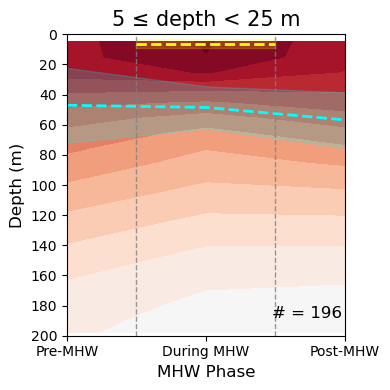

In [8]:
# PLOTTING -------- START
fig, ax = plt.subplots(figsize=(4, 4))

# Calculate data and statistics
indices = np.where((max_temp_depths >= 5) & (max_temp_depths < 25))[0]
print(len(indices))
data = da_vert_temp_comp[indices,:,:].mean(
    dim='mhw_event_ind')

mld_data_mean = np.nanmean(all_mld_stacked[indices,:], axis=0)
mld_data_std = np.nanstd(all_mld_stacked[indices,:], axis=0)

depth_mean = np.nanmean(max_temp_depths[indices], axis=0) 
depth_std = np.nanstd(max_temp_depths[indices], axis=0) 

# # Contour plots
# contour = data.plot.contour(
#     ax=ax,
#     yincrease=False,
#     levels=np.linspace(0.5, 1, 5),
#     cmap='k',
#     linewidths=0.5
# )
contour = data.plot.contourf(
    ax=ax,
    yincrease=False,
    cmap='RdBu_r',
    robust=True,
    levels=25, 
    vmin=-1.2, vmax=1.2,
    add_colorbar=False
)

# # Colorbar
# cbar = plt.colorbar(contour, ax=ax, pad=0.02)
# cbar.set_label("Temperature Anomaly (°C)", fontsize=12)

# Vertical lines
for x in [0.5, 1.5]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=1., alpha=0.8)

# MLD mean line with std shading
plt.plot([0., 1., 2], mld_data_mean, c='cyan', linestyle='dashed', linewidth=2)
# MLD std shading
ax.fill_between([0., 1., 2], 
                mld_data_mean - mld_data_std, 
                mld_data_mean + mld_data_std, 
                color='cyan', alpha=0.2)

# Depth mean line with std shading
ax.hlines(y=depth_mean, xmin=0.5, xmax=1.5, color='yellow', linestyle='dashed', linewidth=2)
# Depth std shading (as a vertical band)
ax.fill_betweenx([depth_mean - depth_std, depth_mean + depth_std], 
                 0.5, 1.5, 
                 color='yellow', alpha=0.2)

# Axis labels and ticks
ax.set_xticks([0., 1., 2])
ax.set_xticklabels(["Pre-MHW", "During MHW", "Post-MHW"], fontsize=10)
ax.set_yticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
ax.set_xlabel("MHW Phase", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)

# Layout and limits
plt.ylim(200, 0)
# plt.title('>100m', fontsize=15)

plt.title('5 ≤ depth < 25 m', fontsize=15)
plt.text(0.99, 0.1, '# = {}'.format(len(indices)), transform=ax.transAxes, 
         fontsize=12, ha='right', va='top')
plt.tight_layout()
plt.show()

In [10]:


# Your data
data_clean = max_temp_depths[~np.isnan(max_temp_depths)]
min_kde = 5.0
data_for_kde = data_clean[data_clean >= min_kde]

print(f"Total data points: {len(data_clean)}")
print(f"Points ≥ {min_kde}m: {len(data_for_kde)}")

# Create KDE
kde = stats.gaussian_kde(data_for_kde)

# Create x values for KDE calculation
x_kde_min = min_kde
x_kde_max = data_for_kde.max() * 1.1
x_kde_range = np.linspace(x_kde_min, x_kde_max, 1000)

# Calculate KDE values
kde_values = kde(x_kde_range)

# **CRITICAL: Calculate area under KDE from min_kde to infinity**
# Use KDE's built-in integration
area_truncated = kde.integrate_box_1d(min_kde, np.inf)
print(f"Area under KDE from {min_kde}m to ∞: {area_truncated:.6f}")

# Normalize the KDE for the truncated region
kde_values_normalized = kde_values / area_truncated

# Convert to percentage
kde_percent = kde_values_normalized * 100

# Create full plotting range
x_plot = np.linspace(0, x_kde_max, 1000)
kde_plot = np.zeros_like(x_plot)

# Interpolate
mask = x_plot >= min_kde
interp_func = interpolate.interp1d(x_kde_range, kde_percent, 
                                   bounds_error=False, fill_value=0)
kde_plot[mask] = interp_func(x_plot[mask])

# Calculate final area
total_area = np.trapz(kde_plot, x_plot)
print(f"Area under plotted curve: {total_area:.2f}%")

Total data points: 407
Points ≥ 5.0m: 407
Area under KDE from 5.0m to ∞: 0.778392
Area under plotted curve: 99.90%


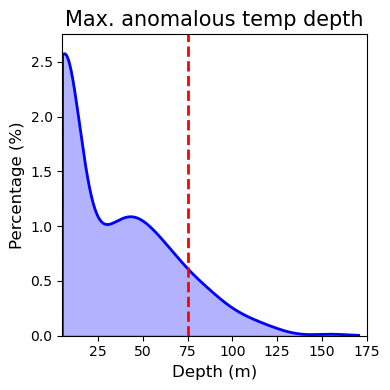

In [11]:
# Plot
plt.figure(figsize=(4, 4))
plt.plot(x_plot, kde_plot, 'b-', linewidth=2)
plt.fill_between(x_plot, kde_plot, alpha=0.3, color='blue')
plt.title('Max. anomalous temp depth', fontsize=15)
plt.xlabel('Depth (m)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
# plt.grid(True, alpha=0.3)
plt.xlim(5, 175)
plt.ylim(0, 2.75)
plt.tight_layout()
plt.axvline(x=75, c='red', linestyle='dashed', linewidth=2)
plt.show()

In [15]:
def calculate_kde_area(x_values, y_values, x_min=None, x_max=None):
    """
    Calculate area under KDE curve between specified limits.
    
    Parameters:
    -----------
    x_values, y_values: arrays for KDE curve
    x_min, x_max: integration limits (use data min/max if None)
    
    Returns:
    --------
    area: float, area under curve
    """
    if x_min is None:
        x_min = x_values.min()
    if x_max is None:
        x_max = x_values.max()
    
    # Filter values within range
    mask = (x_values >= x_min) & (x_values <= x_max)
    if not np.any(mask):
        return 0.0
    
    x_filtered = x_values[mask]
    y_filtered = y_values[mask]
    
    # Integrate
    area = np.trapz(y_filtered, x_filtered)
    return area

# Usage
total_area = calculate_kde_area(x_plot, kde_plot)
area_5_to_25 = calculate_kde_area(x_plot, kde_plot, x_min=5, x_max=25)
area_25_to_50 = calculate_kde_area(x_plot, kde_plot, x_min=25, x_max=50)
area_50_to_75 = calculate_kde_area(x_plot, kde_plot, x_min=50, x_max=75)
area_75_plus = calculate_kde_area(x_plot, kde_plot, x_min=75)

print(f"Total area (0-∞): {total_area:.2f}%")
print(f"Area 5-25m: {area_5_to_25:.2f}% ({area_5_to_25/total_area*100:.1f}% of total)")
print(f"Area 25-50m: {area_25_to_50:.2f}% ({area_25_to_50/total_area*100:.1f}% of total)")
print(f"Area 50-75m: {area_50_to_75:.2f}% ({area_50_to_75/total_area*100:.1f}% of total)")
print(f"Area 75 plus: {area_75_plus:.2f}% ({area_75_plus/total_area*100:.1f}% of total)")

Total area (0-∞): 99.90%
Area 5-25m: 37.09% (37.1% of total)
Area 25-50m: 26.10% (26.1% of total)
Area 50-75m: 20.97% (21.0% of total)
Area 75 plus: 15.05% (15.1% of total)


In [18]:
area_45_to_55 = calculate_kde_area(x_plot, kde_plot, x_min=45, x_max=55)
print(f"Area 5-25m: {area_45_to_55:.2f}% ({area_45_to_55/total_area*100:.1f}% of total)")


Area 5-25m: 10.31% (10.3% of total)


In [19]:
area_65_to_85 = calculate_kde_area(x_plot, kde_plot, x_min=65, x_max=85)
print(f"Area 5-25m: {area_65_to_85:.2f}% ({area_65_to_85/total_area*100:.1f}% of total)")


Area 5-25m: 12.32% (12.3% of total)


In [22]:
area_65_to_85 = calculate_kde_area(x_plot, kde_plot, x_min=75, x_max=150)
print(f"Area 5-25m: {area_65_to_85:.2f}% ({area_65_to_85/total_area*100:.1f}% of total)")


Area 5-25m: 14.84% (14.9% of total)


In [23]:
area_65_to_85 = calculate_kde_area(x_plot, kde_plot, x_min=45, x_max=150)
print(f"Area 5-25m: {area_65_to_85:.2f}% ({area_65_to_85/total_area*100:.1f}% of total)")


Area 5-25m: 41.20% (41.2% of total)
